# Análise comparativa de representações

Base **demonstrativa sintética**, autorizada para substituir a base oficial ausente. São 40 manifestações fictícias, seis pares rotulados e cinco textos com mais de 500 caracteres. Os pares M003/M017, M008/M022 e M008/M031 mantêm os temas indicados no enunciado. O gabarito não foi usado para treinar os modelos. Os resultados abaixo são de execução real, não valores ilustrativos.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.metrics.pairwise import cosine_similarity
from ouvidoria import carregar_base, codificar, detectar_duplicatas, dividir, projetar, MODELOS
df = carregar_base()
Path('resultados').mkdir(exist_ok=True)
pd.set_option('display.max_colwidth', 160)
display(df.head())


C:\Users\Usuario\Desktop\ricardo\.venv-validacao\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,id,data,categoria_oficial,texto
0,M001,2026-08-01,infraestrutura,A calçada da Rua das Flores está quebrada em frente ao número 20. Pessoas com cadeira de rodas precisam circular pela pista.
1,M002,2026-08-02,meio ambiente,"Há lixo acumulado no terreno da Rua do Sol, ao lado do número 45. O descarte atrai moscas e produz mau cheiro."
2,M003,2026-08-03,infraestrutura,"Há um buraco enorme na Av. Brasil, perto do número 100, sentido centro. A cratera causa acidentes e precisa de reparo."
3,M004,2026-08-04,educação,A Escola Municipal Aurora está sem professor de matemática no oitavo ano há três semanas. Pedimos reposição das aulas.
4,M005,2026-08-05,segurança,Moradores relatam assaltos no ponto de ônibus da Rua das Acácias à noite. Solicitamos patrulhamento no local.


BoW conta ocorrências; TF-IDF reduz o peso de termos comuns; os dois modelos densos usam embeddings multilíngues normalizados. O mesmo corpus é usado em todas as representações, sem acrescentar as categorias ao texto.

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4849.27it/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1046.09it/s]

,BoW,TF-IDF,paraphrase-multilingual-MiniLM-L12-v2,distiluse-base-multilingual-cased-v2
Par,,,,
M003 × M017,0.4617,0.4649,0.7610,0.7518
M008 × M022,0.7628,0.7225,0.9338,0.9150
M008 × M031,0.1754,0.0523,0.0575,0.0747


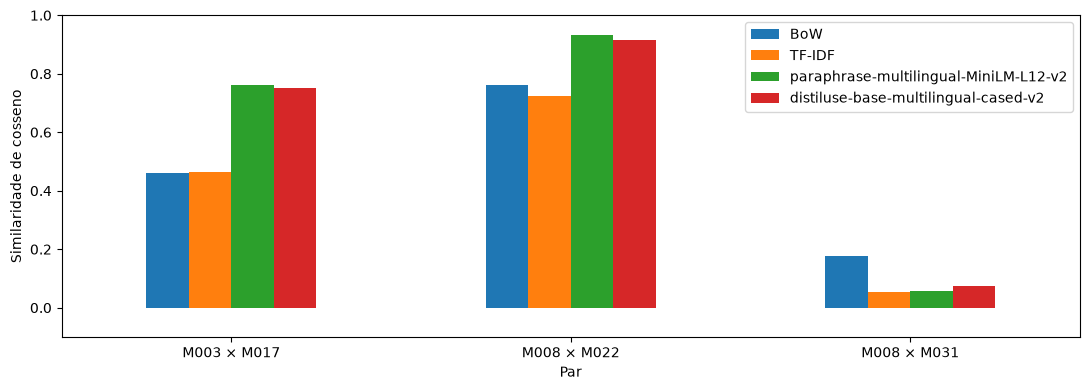

In [2]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import silhouette_score
representacoes = {
    'BoW': CountVectorizer().fit_transform(df.texto),
    'TF-IDF': TfidfVectorizer().fit_transform(df.texto),
}
for nome in MODELOS:
    representacoes[nome.split('/')[-1]] = codificar(df.texto, nome)
pares = [('M003','M017'), ('M008','M022'), ('M008','M031')]
linhas = []
for a,b in pares:
    i,j = df.index[df.id == a][0], df.index[df.id == b][0]
    linhas.append({'Par': f'{a} × {b}', **{nome:float(cosine_similarity(v[i:i+1],v[j:j+1])[0,0]) for nome,v in representacoes.items()}})
tabela = pd.DataFrame(linhas).set_index('Par')
display(tabela.round(4))
tabela.to_csv('resultados/comparacao.csv')
ax = tabela.plot.bar(figsize=(11,4), ylim=(-.1,1), rot=0)
ax.set_ylabel('Similaridade de cosseno')
plt.tight_layout(); plt.savefig('resultados/comparacao.png', dpi=160); plt.show()


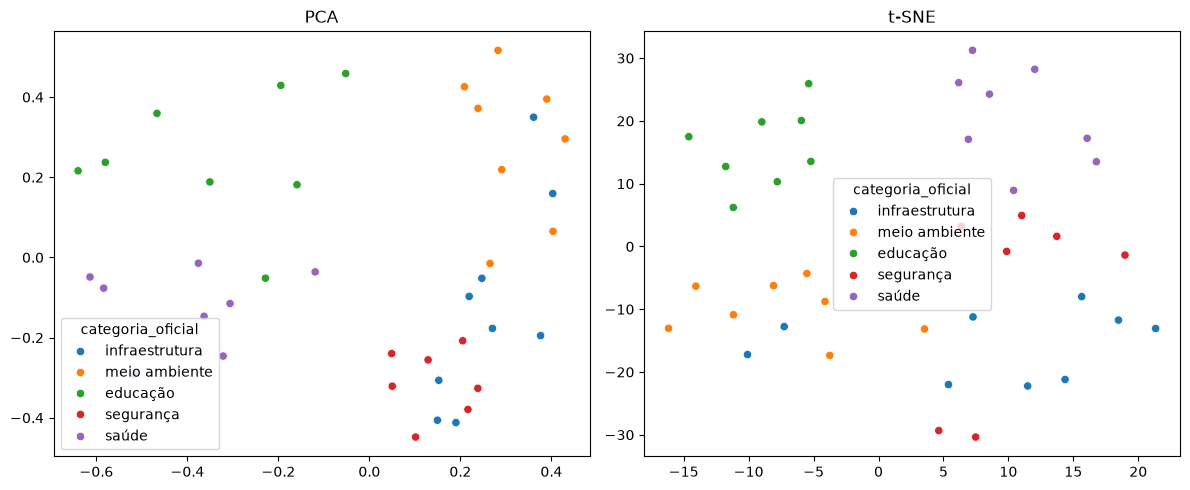

Silhouette por categoria oficial no espaço original: **0.136**. Valores perto de zero indicam sobreposição; positivos indicam maior coesão interna. Categorias foram usadas apenas na avaliação, não para gerar embeddings.

34

In [3]:
vetores = representacoes[MODELOS[0].split('/')[-1]]
fig, axs = plt.subplots(1,2,figsize=(12,5))
for ax,metodo in zip(axs,['PCA','t-SNE']):
    xy = projetar(vetores,metodo)
    sns.scatterplot(x=xy[:,0],y=xy[:,1],hue=df.categoria_oficial,ax=ax)
    ax.set_title(metodo)
plt.tight_layout(); plt.savefig('resultados/espaco_vetorial.png',dpi=150); plt.show()
sil = silhouette_score(vetores, df.categoria_oficial, metric='cosine')
display(Markdown(f'Silhouette por categoria oficial no espaço original: **{sil:.3f}**. Valores perto de zero indicam sobreposição; positivos indicam maior coesão interna. Categorias foram usadas apenas na avaliação, não para gerar embeddings.'))
Path('resultados/silhouette.json').write_text(json.dumps({'silhouette':float(sil)}))


**Conclusão.** BoW e TF-IDF dependem da interseção de palavras e não reconhecem sinonímia por si só. TF-IDF ajuda a reduzir termos frequentes, mas pode valorizar nomes e locais raros. Os embeddings aproximam paráfrases, porém também podem aproximar denúncias do mesmo tema que se referem a eventos distintos. Os escores não são probabilidades. Nesta base construída, os pares positivos compartilham localização e fatos; portanto o experimento é pequeno e favorece exemplos conhecidos. A comparação de dois modelos e o par negativo ajudam a diagnosticar o comportamento, mas não permitem afirmar superioridade universal. PCA maximiza variância e t-SNE privilegia vizinhanças; a separação visual deve ser confrontada com a silhouette no espaço original.

### Leitura dos resultados medidos
+
+M003/M017: BoW **0,462**, TF-IDF **0,465**, MiniLM **0,761** e DistilUSE **0,752**. As paráfrases sobre a mesma avenida se aproximaram mais nos modelos densos. M008/M022: **0,763**, **0,723**, **0,934** e **0,915**, respectivamente; a reformulação do atendimento no PSF preservou alta similaridade. M008/M031: **0,175**, **0,052**, **0,057** e **0,075**; todos separaram razoavelmente saúde e iluminação, com BoW mais afetado por palavras comuns. MiniLM foi ligeiramente maior nos pares positivos e menor no negativo que DistilUSE, mas três pares de uma base sintética são insuficientes para generalizar essa vantagem. A silhouette de **0,136** sugere grupos apenas parcialmente separados, coerente com relatos multitemáticos.